In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

In [2]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance (1).csv


In [3]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Created a new column
If BMI > 30 → 1 else 0
Helps model understand health risk easily

In [4]:
df['is_obese'] = (df['bmi'] > 30).astype(int)

In [5]:
df[['bmi', 'is_obese']].head()

,bmi,is_obese
0,27.900,0
1,33.770,1
2,33.000,1
3,22.705,0
4,28.880,0


No.of rows,
No. of columns

In [6]:
df.shape

(1338, 8)

Shows all feature names.

In [7]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'is_obese'],
      dtype='object')

Shows:

Data types

Null values

Memory usage

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
 7   is_obese  1338 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 83.8+ KB


Statistical summary:

mean

std

min

max

quartiles

In [9]:
df.describe()

,age,bmi,children,charges,is_obese
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265,0.526906
std,14.049960,6.098187,1.205493,12110.011237,0.499462
min,18.000000,15.960000,0.000000,1121.873900,0.000000
25%,27.000000,26.296250,0.000000,4740.287150,0.000000
50%,39.000000,30.400000,1.000000,9382.033000,1.000000
75%,51.000000,34.693750,2.000000,16639.912515,1.000000
max,64.000000,53.130000,5.000000,63770.428010,1.000000


If all are 0 → say:

“Dataset contains no missing values.”

In [10]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0
is_obese,0


This tells unique values in each column.

In [11]:
df.nunique()

,0
age,47
sex,2
bmi,548
children,6
smoker,2
region,4
charges,1337
is_obese,2


Graphs-->

1️⃣ Distribution of Age

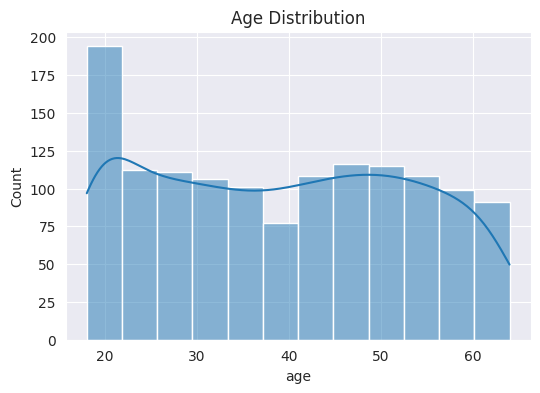

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

2️⃣ BMI Distribution

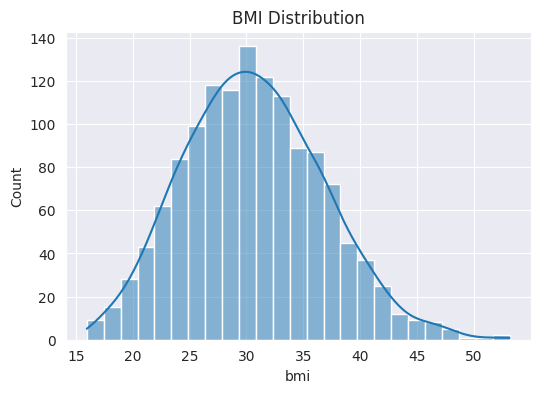

In [13]:
plt.figure(figsize=(6,4))
sns.histplot(df['bmi'], kde=True)
plt.title("BMI Distribution")
plt.show()

3️⃣ Charges Distribution

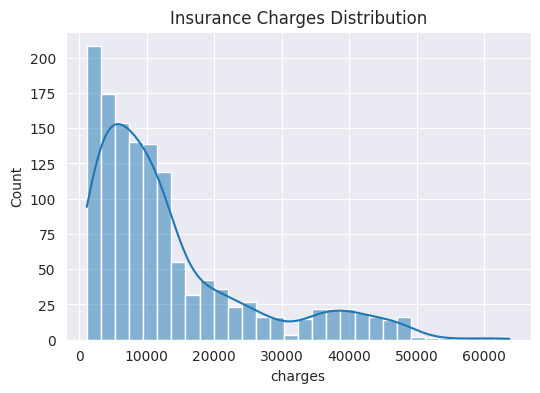

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(df['charges'], kde=True)
plt.title("Insurance Charges Distribution")
plt.show()

4️⃣ Smoker vs Charges (VERY IMPORTANT GRAPH)

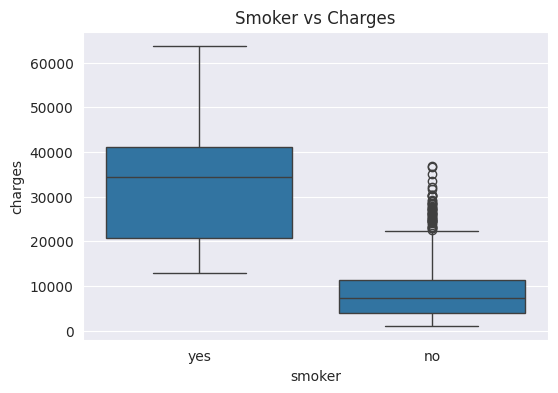

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoker vs Charges")
plt.show()

5️⃣ Correlation Heatmap

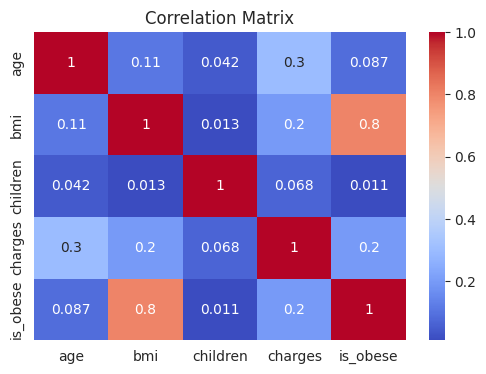

In [16]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

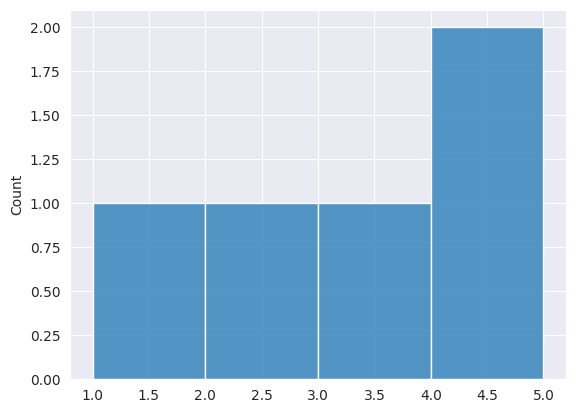

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("darkgrid")
sns.histplot([1,2,3,4,5])
plt.show()

💡 What you did:
Changed text to numbers
🧠 Why:

Model only understands numbers

In [18]:
df['sex'] = df['sex'].map({'male':0, 'female':1})
df['smoker'] = df['smoker'].map({'yes':1, 'no':0})

df = pd.get_dummies(df, columns=['region'], drop_first=True)

X	 --->       input (features)||
y	 --->       output (target)||
(age, bmi, smoker...) → charges


In [19]:
X = df.drop('charges', axis=1)
y = df['charges']

💡 What you did:
Divided data into 2 parts

Train	--> Learn,

Test  -->	Check


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

💡 What you did:

👉 Gave data to model

🧠 Meaning:

Model learns patterns

In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

💡 What you did:

👉 Asked model to predict

🧠 Meaning:

Model gives answers for new data

In [22]:
y_pred = model.predict(X_test)

💡 What you did:

👉 Checked accuracy

🧠 Meaning:
Close to 1 → good
Close to 0 → bad

In [23]:
from sklearn.metrics import r2_score

print(r2_score(y_test, y_pred))

0.7843676348248796


💡 What you did:

👉 Used better model

🧠 Why:
Linear model = simple

Random Forest = smarter (handles complex patterns)

In [24]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(r2_score(y_test, y_pred))

0.8640498660179113


## Dataset Overview
This dataset contains medical insurance records...

## Key Observations
1. Smokers pay significantly higher charges.
2. Charges are right-skewed.
3. Age moderately affects charges.